## Trial-relative time
Compute t_rel_ms per trial: time relative to trial onset.

In [6]:
import pandas as pd

def add_relative_time(df: pd.DataFrame, time_col: str = "time_ms") -> pd.DataFrame:
    """
    Add a column t_rel_ms = time within trial (ms),
    computed as time_ms - min(time_ms) per trial.

    Uses transform("min") instead of a Python lambda, which is much faster.
    """
    if time_col not in df.columns:
        raise ValueError(f"{time_col} column missing.")
    if "trial" not in df.columns:
        raise ValueError("trial column missing.")

    df = df.copy()

    # make sure time_ms is numeric
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")

    # relative time = time_ms - first time_ms in that trial (min)
    trial_min = df.groupby("trial")[time_col].transform("min")
    df["t_rel_ms"] = df[time_col] - trial_min

    return df

##  Baseline correction function

In [10]:
import pandas as pd
from pathlib import Path

# ---------- 1) Helpers ----------

def find_pupil_columns(df: pd.DataFrame):
    """
    Try to detect left/right pupil diameter columns in mm.
    Returns (left_col, right_col) or (None, None) if not found.
    """
    left_col = None
    right_col = None

    for c in df.columns:
        cl = c.lower()
        if "pupil" in cl and "left" in cl and "mm" in cl:
            left_col = c
        if "pupil" in cl and "right" in cl and "mm" in cl:
            right_col = c

    return left_col, right_col


def drop_rows_without_pupil(df: pd.DataFrame, left_col: str | None, right_col: str | None) -> pd.DataFrame:
    """
    Drop rows where both pupil columns (if present) are missing/empty.
    """
    cols = [c for c in [left_col, right_col] if c is not None and c in df.columns]
    if not cols:
        return df

    df = df.copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    mask_has_any = df[cols].notna().any(axis=1)
    return df[mask_has_any].reset_index(drop=True)


def add_relative_time(df: pd.DataFrame, time_col: str = "time_ms") -> pd.DataFrame:
    """
    Fast relative time: t_rel_ms = time_ms - min(time_ms) per trial.
    """
    if time_col not in df.columns:
        raise ValueError(f"{time_col} column missing.")
    if "trial" not in df.columns:
        raise ValueError("trial column missing.")

    df = df.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")

    trial_min = df.groupby("trial")[time_col].transform("min")
    df["t_rel_ms"] = df[time_col] - trial_min
    return df


def baseline_correct_pupil(
    df: pd.DataFrame,
    baseline_window_ms: int = 500,
    time_rel_col: str = "t_rel_ms",
    pupil_cols=(),
) -> pd.DataFrame:
    """
    Baseline-correct given pupil columns per trial using the mean pupil size
    in the first `baseline_window_ms` ms. Adds <col>_bc columns.
    """
    if "trial" not in df.columns:
        raise ValueError("trial column missing.")
    if time_rel_col not in df.columns:
        raise ValueError(f"{time_rel_col} column missing. Run add_relative_time() first.")

    df = df.copy()

    # prepare new columns
    for col in pupil_cols:
        if col in df.columns:
            df[col + "_bc"] = pd.NA

    for trial_id, tdf in df.groupby("trial"):
        idx = tdf.index
        baseline_mask = tdf[time_rel_col] <= baseline_window_ms
        if not baseline_mask.any():
            continue

        for col in pupil_cols:
            if col not in df.columns:
                continue

            baseline_values = pd.to_numeric(
                tdf.loc[baseline_mask, col],
                errors="coerce"
            )

            if baseline_values.notna().sum() == 0:
                trial_values = pd.to_numeric(tdf[col], errors="coerce")
                if trial_values.notna().sum() == 0:
                    continue
                baseline = trial_values.mean()
            else:
                baseline = baseline_values.mean()

            trial_numeric = pd.to_numeric(df.loc[idx, col], errors="coerce")
            df.loc[idx, col + "_bc"] = trial_numeric - baseline

    return df


# ---------- 2) Apply to all participants ----------

trimmed_dir = Path("../data/by_participant_trimmed")
baseline_dir = Path("../data/by_participant_baseline")
baseline_dir.mkdir(parents=True, exist_ok=True)

summary = []

for csv_path in sorted(trimmed_dir.glob("participant_*.csv")):
    df = pd.read_csv(csv_path, low_memory=False)

    if "trial" not in df.columns or "time_ms" not in df.columns:
        print(f"Skipping {csv_path.name}: missing 'trial' or 'time_ms'")
        continue

    # detect pupil columns
    left_col, right_col = find_pupil_columns(df)
    if left_col is None and right_col is None:
        print(f"{csv_path.name}: no pupil columns found, skipping baseline.")
        continue

    pupil_cols = [c for c in [left_col, right_col] if c is not None]

    # drop rows with no pupil in either eye
    df = drop_rows_without_pupil(df, left_col, right_col)

    # add t_rel_ms
    if "t_rel_ms" not in df.columns:
        df = add_relative_time(df, time_col="time_ms")

    # baseline correct
    df_bc = baseline_correct_pupil(
        df,
        baseline_window_ms=500,
        time_rel_col="t_rel_ms",
        pupil_cols=pupil_cols,
    )

    # build unified names: if your original cols are e.g. "Pupil Diameter Left [mm]"
    # you will get "Pupil Diameter Left [mm]_bc" etc. That’s fine, or you can rename:
    rename_map = {}
    if left_col and left_col + "_bc" in df_bc.columns:
        rename_map[left_col + "_bc"] = "pupil_left_bc"
    if right_col and right_col + "_bc" in df_bc.columns:
        rename_map[right_col + "_bc"] = "pupil_right_bc"
    df_bc = df_bc.rename(columns=rename_map)

    # save
    out_path = baseline_dir / csv_path.name
    df_bc.to_csv(out_path, index=False)

    # quick stats
    stats = {}
    for col in ["pupil_left_bc", "pupil_right_bc"]:
        if col in df_bc.columns:
            s = pd.to_numeric(df_bc[col], errors="coerce")
            stats[col] = (s.min(), s.max())
        else:
            stats[col] = (None, None)

    pid = csv_path.stem.split("_")[-1]
    summary.append((pid, stats))

    print(
        f"{csv_path.name}: baseline corrected. "
        f"left_bc={stats['pupil_left_bc']}, right_bc={stats['pupil_right_bc']}"
    )

print("\n=== Baseline correction summary (min, max per pupil_bc column) ===")
for pid, stats in summary:
    print(f"Participant {pid}: {stats}")

participant_1.csv: baseline corrected. left_bc=(-1.805800000000001, 1.6839192307692308), right_bc=(-1.4809000000000019, 1.6277)
participant_10.csv: baseline corrected. left_bc=(-1.3511269230769232, 0.6210000000000004), right_bc=(-1.072907692307692, 1.0287000000000006)
participant_11.csv: baseline corrected. left_bc=(-1.6996000000000002, 1.6349846153846164), right_bc=(-3.2394, 4.6964999999999995)
participant_13.csv: baseline corrected. left_bc=(-1.2193769230769238, 6.120107692307692), right_bc=(-1.6048, 2.167580769230769)
participant_14.csv: baseline corrected. left_bc=(-2.943373076923077, 2.8688461538461536), right_bc=(-3.3503, 3.1602000000000006)
participant_15.csv: baseline corrected. left_bc=(-4.070983333333333, 6.004415384615386), right_bc=(-4.361533333333333, 3.1760000000000006)
participant_17.csv: baseline corrected. left_bc=(-3.660200000000001, 6.574700000000002), right_bc=(-4.591846153846154, 4.1273)
participant_18.csv: baseline corrected. left_bc=(-3.3331384615384616, 4.872507

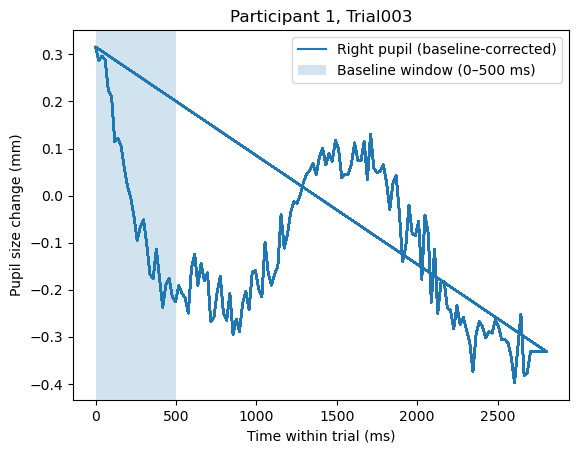

In [19]:
import matplotlib.pyplot as plt

example_path = baseline_dir / "participant_3.csv"  # change ID if you like
df_ex = pd.read_csv(example_path, low_memory=False)

trial_id = "Trial003"  # or another
sub = df_ex[df_ex["trial"] == trial_id]

plt.figure()
plt.plot(sub["t_rel_ms"], sub["pupil_right_bc"], label="Right pupil (baseline-corrected)", drawstyle='default')
plt.axvspan(0, 500, alpha=0.2, label="Baseline window (0–500 ms)")
plt.xlabel("Time within trial (ms)")
plt.ylabel("Pupil size change (mm)")
plt.title(f"Participant 1, {trial_id}")
plt.legend()
plt.show()

In [ ]:
from pathlib import Path
import pandas as pd

# =========================
# 1) Helpers
# =========================

def find_pupil_columns(df: pd.DataFrame):
    """
    Detect left/right pupil diameter columns in mm.
    Returns (left_col, right_col) or (None, None) if not found.
    """
    left_col = None
    right_col = None

    for c in df.columns:
        cl = c.lower()
        if "pupil" in cl and "left" in cl and "mm" in cl:
            left_col = c
        if "pupil" in cl and "right" in cl and "mm" in cl:
            right_col = c

    return left_col, right_col


def drop_rows_without_pupil(df: pd.DataFrame, left_col: str | None, right_col: str | None) -> pd.DataFrame:
    """
    Drop rows where both pupil columns (if present) are missing/empty.
    NOTE: If you need blink-rate later, compute blinks BEFORE dropping rows.
    """
    cols = [c for c in [left_col, right_col] if c is not None and c in df.columns]
    if not cols:
        return df

    df = df.copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    mask_has_any = df[cols].notna().any(axis=1)
    return df[mask_has_any].reset_index(drop=True)


def add_relative_time(df: pd.DataFrame, time_col: str = "time_ms") -> pd.DataFrame:
    """
    Add t_rel_ms = time_ms - min(time_ms) per trial.
    """
    if time_col not in df.columns:
        raise ValueError(f"{time_col} column missing.")
    if "trial" not in df.columns:
        raise ValueError("trial column missing.")

    df = df.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")

    trial_min = df.groupby("trial")[time_col].transform("min")
    df["t_rel_ms"] = df[time_col] - trial_min
    return df


def baseline_correct_pupil(
    df: pd.DataFrame,
    baseline_window_ms: int = 500,
    time_rel_col: str = "t_rel_ms",
    left_pupil_col: str = "pupil_left_mm",
    right_pupil_col: str = "pupil_right_mm",
    left_cat_col: str = "category_left",
    right_cat_col: str = "category_right",
    tracking_col: str | None = "tracking_ratio_[%]",
    min_tracking_ratio: float | None = None,
    min_valid_baseline_samples: int = 5,
) -> pd.DataFrame:
    """
    Baseline-correct left/right pupil per trial using mean in first 500ms,
    excluding samples labeled Blink (per eye), plus optional tracking threshold.
    Produces pupil_left_bc and pupil_right_bc.
    """
    df = df.copy()

    if tracking_col and tracking_col in df.columns:
        df[tracking_col] = pd.to_numeric(df[tracking_col], errors="coerce")

    df["pupil_left_bc"] = pd.NA
    df["pupil_right_bc"] = pd.NA

    for trial_id, tdf in df.groupby("trial"):
        idx = tdf.index
        t_rel = pd.to_numeric(tdf[time_rel_col], errors="coerce")
        baseline_window = t_rel <= baseline_window_ms
        if not baseline_window.any():
            continue

        # optional tracking quality gate
        if min_tracking_ratio is not None and tracking_col in tdf.columns:
            track_ok = tdf[tracking_col] >= float(min_tracking_ratio)
        else:
            track_ok = pd.Series(True, index=tdf.index)

        # ---- LEFT ----
        if left_pupil_col in tdf.columns:
            pupil_l = pd.to_numeric(tdf[left_pupil_col], errors="coerce")
            not_blink_l = ~(tdf[left_cat_col].astype(str).str.lower() == "blink") if left_cat_col in tdf.columns else True
            valid_base_l = baseline_window & track_ok & not_blink_l & pupil_l.notna() & (pupil_l > 0)

            if valid_base_l.sum() >= min_valid_baseline_samples:
                base_l = pupil_l.loc[valid_base_l].mean()
                df.loc[idx, "pupil_left_bc"] = pd.to_numeric(df.loc[idx, left_pupil_col], errors="coerce") - base_l

        # ---- RIGHT ----
        if right_pupil_col in tdf.columns:
            pupil_r = pd.to_numeric(tdf[right_pupil_col], errors="coerce")
            not_blink_r = ~(tdf[right_cat_col].astype(str).str.lower() == "blink") if right_cat_col in tdf.columns else True
            valid_base_r = baseline_window & track_ok & not_blink_r & pupil_r.notna() & (pupil_r > 0)

            if valid_base_r.sum() >= min_valid_baseline_samples:
                base_r = pupil_r.loc[valid_base_r].mean()
                df.loc[idx, "pupil_right_bc"] = pd.to_numeric(df.loc[idx, right_pupil_col], errors="coerce") - base_r

    return df


# =========================
# 2) Pipeline: apply to all participants
# =========================

def run_baseline_pipeline(
    trimmed_dir: str | Path = "../data/by_participant_trimmed",
    out_dir: str | Path = "../data/by_participant_baseline2",
    baseline_window_ms: int = 500,
    min_tracking_ratio: float | None = None,     # set e.g. 80.0 if you want to gate by tracking quality
    min_valid_baseline_samples: int = 5,
):
    trimmed_dir = Path(trimmed_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    summary = []

    for csv_path in sorted(trimmed_dir.glob("participant_*.csv")):
        df = pd.read_csv(csv_path, low_memory=False)

        # sanity check
        if "trial" not in df.columns or "time_ms" not in df.columns:
            print(f"Skipping {csv_path.name}: missing 'trial' or 'time_ms'")
            continue

        # detect pupil columns
        left_col, right_col = find_pupil_columns(df)
        if left_col is None and right_col is None:
            print(f"{csv_path.name}: no pupil columns found, skipping.")
            continue

        pupil_cols = [c for c in [left_col, right_col] if c is not None]

        # IMPORTANT: if you might already have old *_bc columns, drop them
        df = df.drop(columns=[c for c in df.columns if c.endswith("_bc")], errors="ignore")

        # drop rows where both pupils are missing
        df = drop_rows_without_pupil(df, left_col, right_col)

        # add relative time per trial
        if "t_rel_ms" not in df.columns:
            df = add_relative_time(df, time_col="time_ms")

        # baseline correct (masked baseline window)
        df_bc = baseline_correct_pupil(
            df,
            baseline_window_ms=baseline_window_ms,
            time_rel_col="t_rel_ms",
            pupil_cols=pupil_cols,
            min_tracking_ratio=min_tracking_ratio,
            min_valid_baseline_samples=min_valid_baseline_samples,
            overwrite_existing_bc=True,
        )

        # rename to unified columns (optional)
        rename_map = {}
        if left_col and left_col + "_bc" in df_bc.columns:
            rename_map[left_col + "_bc"] = "pupil_left_bc"
        if right_col and right_col + "_bc" in df_bc.columns:
            rename_map[right_col + "_bc"] = "pupil_right_bc"
        df_bc = df_bc.rename(columns=rename_map)

        # save output
        out_path = out_dir / csv_path.name
        df_bc.to_csv(out_path, index=False)

        # quick stats
        stats = {}
        for col in ["pupil_left_bc", "pupil_right_bc"]:
            if col in df_bc.columns:
                s = pd.to_numeric(df_bc[col], errors="coerce")
                stats[col] = {
                    "n": int(s.notna().sum()),
                    "min": float(s.min()) if s.notna().any() else None,
                    "max": float(s.max()) if s.notna().any() else None,
                }
            else:
                stats[col] = {"n": 0, "min": None, "max": None}

        pid = csv_path.stem.split("_")[-1]
        summary.append((pid, stats))

        print(f"{csv_path.name}: saved -> {out_path.name} | {stats}")

    print("\n=== Baseline correction summary ===")
    for pid, stats in summary:
        print(f"Participant {pid}: {stats}")


# =========================
# 3) Run
# =========================

if __name__ == "__main__":
    run_baseline_pipeline(
        trimmed_dir="../data/by_participant_trimmed",
        out_dir="../data/by_participant_baseline2",
        baseline_window_ms=500,
        min_tracking_ratio=None,          # set to 80.0 if you want a tracking-quality gate
        min_valid_baseline_samples=5,     # adjust to your sampling rate (e.g. 10-20 if 120 Hz)
    )

participant_1.csv: saved -> participant_1.csv | {'pupil_left_bc': {'n': 22862, 'min': -1.805800000000001, 'max': 1.6839192307692308}, 'pupil_right_bc': {'n': 22862, 'min': -1.4809000000000019, 'max': 1.6277}}
participant_10.csv: saved -> participant_10.csv | {'pupil_left_bc': {'n': 22633, 'min': -1.3511269230769232, 'max': 0.6210000000000004}, 'pupil_right_bc': {'n': 22633, 'min': -1.072907692307692, 'max': 1.0287000000000006}}
participant_11.csv: saved -> participant_11.csv | {'pupil_left_bc': {'n': 17795, 'min': -1.6996000000000002, 'max': 1.6349846153846164}, 'pupil_right_bc': {'n': 68614, 'min': -3.2394, 'max': 4.6964999999999995}}
participant_13.csv: saved -> participant_13.csv | {'pupil_left_bc': {'n': 148701, 'min': -1.2193769230769238, 'max': 6.120107692307692}, 'pupil_right_bc': {'n': 148701, 'min': -1.6048, 'max': 2.167580769230769}}
participant_14.csv: saved -> participant_14.csv | {'pupil_left_bc': {'n': 147340, 'min': -2.943373076923077, 'max': 2.8688461538461536}, 'pupil_

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_eye_sample_balance(
    baseline_dir: str | Path,
    left_col: str = "pupil_left_bc",
    right_col: str = "pupil_right_bc",
):
    """
    Plot number of valid baseline-corrected samples per participant and eye.
    """

    baseline_dir = Path(baseline_dir)
    records = []

    for csv_path in sorted(baseline_dir.glob("participant_*.csv")):
        pid = csv_path.stem.split("_")[-1]
        df = pd.read_csv(csv_path, low_memory=False)

        n_left = (
            pd.to_numeric(df[left_col], errors="coerce").notna().sum()
            if left_col in df.columns
            else 0
        )
        n_right = (
            pd.to_numeric(df[right_col], errors="coerce").notna().sum()
            if right_col in df.columns
            else 0
        )

        records.append((pid, n_left, n_right))

    summary = pd.DataFrame(
        records, columns=["participant", "left_n", "right_n"]
    ).sort_values("participant")

    # ---- plotting ----
    x = range(len(summary))
    width = 0.4

    plt.figure(figsize=(14, 6))
    plt.bar(x, summary["left_n"], width=width, label="Left eye")
    plt.bar(
        [i + width for i in x],
        summary["right_n"],
        width=width,
        label="Right eye",
    )

    plt.xticks(
        [i + width / 2 for i in x],
        summary["participant"],
        rotation=90,
    )
    plt.ylabel("Number of valid baseline-corrected samples")
    plt.xlabel("Participant")
    plt.title("Baseline-corrected pupil sample availability per eye")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary

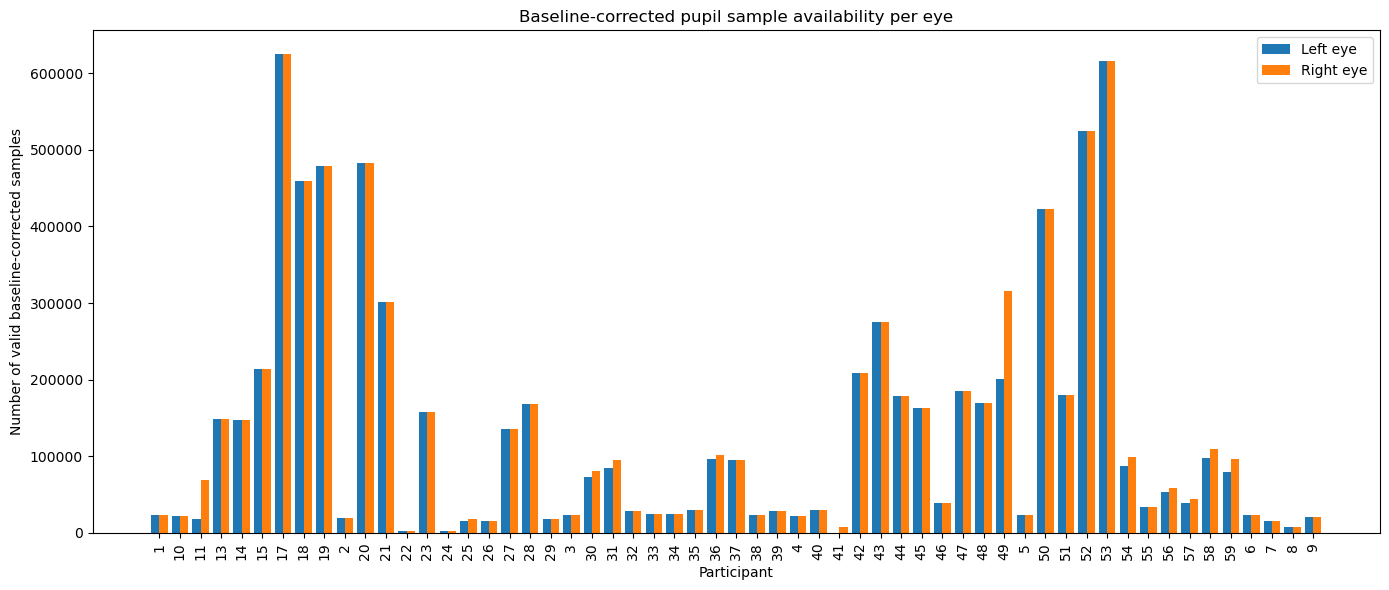

In [2]:
summary_df = plot_eye_sample_balance(
    baseline_dir="../data/by_participant_baseline2"
)

In [24]:
df = pd.read_csv("../data/by_participant_trimmed/participant_1.csv")
(df["pupil_left_mm"] == df["pupil_right_mm"]).mean()

np.float64(0.008673982843724542)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_total_raw_samples(
    data_dir: str | Path,
):
    """
    Plot total number of raw samples recorded per participant
    (number of rows in each participant CSV).
    """
    data_dir = Path(data_dir)
    records = []

    for csv_path in sorted(data_dir.glob("participant_*.csv")):
        pid = csv_path.stem.split("_")[-1]
        df = pd.read_csv(csv_path, low_memory=False)

        n_rows = len(df)
        records.append((pid, n_rows))

    summary = pd.DataFrame(
        records, columns=["participant", "raw_samples"]
    ).sort_values("participant")

    # ---- plot ----
    plt.figure(figsize=(14, 6))
    plt.bar(summary["participant"], summary["raw_samples"])
    plt.xticks(rotation=90)
    plt.ylabel("Number of raw recorded samples")
    plt.xlabel("Participant")
    plt.title("Total raw pupil samples recorded per participant")
    plt.tight_layout()
    plt.show()

    return summary

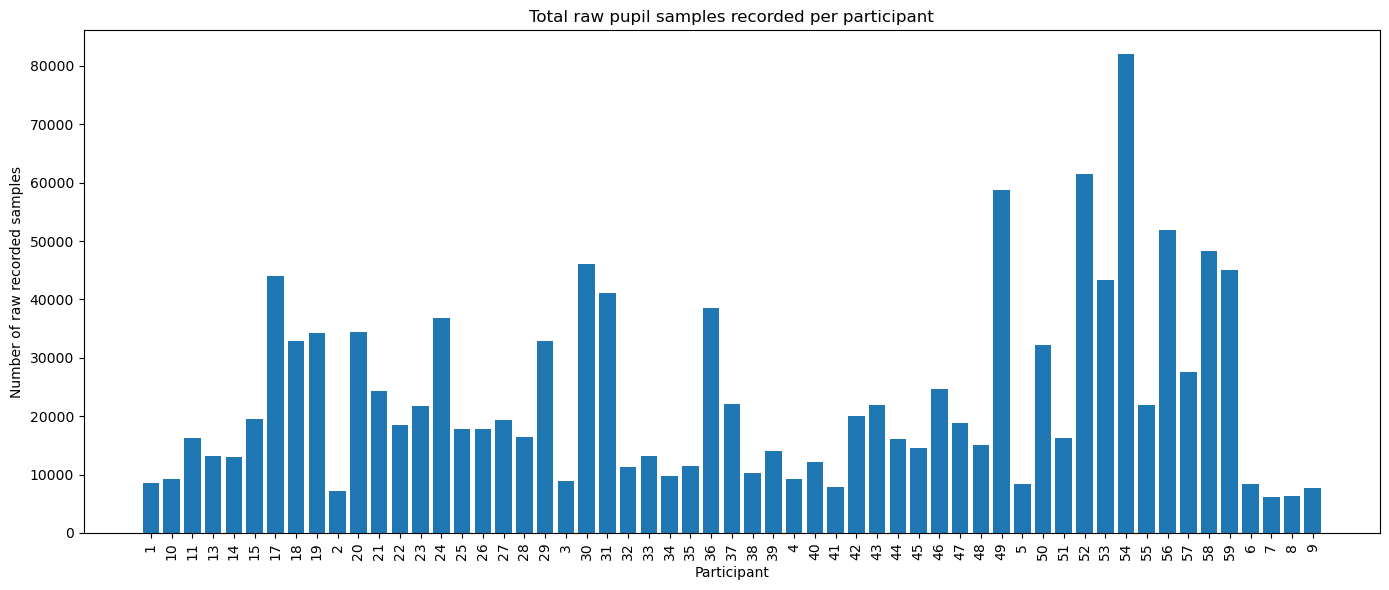

In [4]:
raw_summary = plot_total_raw_samples(
    data_dir="../data/by_participant"
)

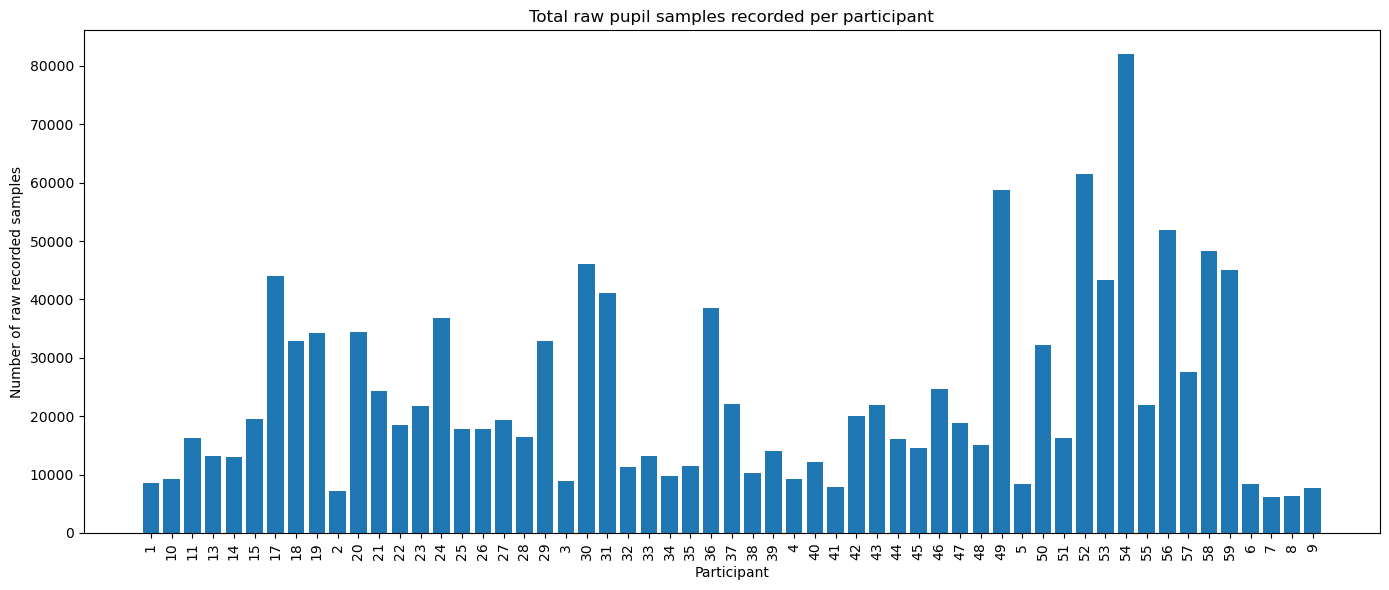

In [6]:
raw_summary = plot_total_raw_samples(
    data_dir="../data/by_participant"
)

In [7]:
import pandas as pd
from pathlib import Path


def compute_trial_lengths_by_type(
    data_dir: str | Path,
    trial_type_col: str = "stim_category",
):
    """
    Compute trial durations per participant and trial type.

    Trial duration is computed as:
        trial_end_ms - trial_start_ms

    Returns a summary DataFrame with:
        participant, trial_type, n_trials,
        mean_duration_ms, min_duration_ms, max_duration_ms, total_duration_ms
    """
    data_dir = Path(data_dir)
    records = []

    for csv_path in sorted(data_dir.glob("participant_*.csv")):
        pid = csv_path.stem.split("_")[-1]
        df = pd.read_csv(csv_path, low_memory=False)

        required = ["trial", "trial_start_ms", "trial_end_ms", trial_type_col]
        if not all(c in df.columns for c in required):
            continue

        # one row per trial
        trials = (
            df[["trial", "trial_start_ms", "trial_end_ms", trial_type_col]]
            .drop_duplicates(subset="trial")
            .copy()
        )

        trials["trial_start_ms"] = pd.to_numeric(trials["trial_start_ms"], errors="coerce")
        trials["trial_end_ms"] = pd.to_numeric(trials["trial_end_ms"], errors="coerce")

        trials["duration_ms"] = trials["trial_end_ms"] - trials["trial_start_ms"]
        trials = trials.dropna(subset=["duration_ms"])

        for trial_type, tdf in trials.groupby(trial_type_col):
            records.append({
                "participant": pid,
                "trial_type": trial_type,
                "n_trials": len(tdf),
                "mean_duration_ms": tdf["duration_ms"].mean(),
                "min_duration_ms": tdf["duration_ms"].min(),
                "max_duration_ms": tdf["duration_ms"].max(),
                "total_duration_ms": tdf["duration_ms"].sum(),
            })

    summary = pd.DataFrame(records)
    return summary

In [8]:
trial_length_summary = compute_trial_lengths_by_type(
    data_dir="../data/by_participant_trimmed",
    trial_type_col="stim_category",  # or "stimulus" if you prefer
)

In [10]:
trial_length_summary.groupby("trial_type")[["mean_duration_ms"]].describe()

mean_duration_ms                                          \
                           count          mean         std           min   
trial_type                                                                 
ballon_left                 13.0  52226.101000   19.213351  52181.765000   
ballon_right                24.0  52057.249000   65.559303  51993.177000   
cat_eyes_left               34.0   2883.352294   17.407962   2824.101000   
cat_eyes_right              20.0   2855.551300   54.448060   2684.497000   
cat_head_left               33.0   2883.412030   13.696201   2848.053000   
cat_head_right              20.0   2870.923200   41.538777   2713.918000   
cat_point_left              34.0   2879.310191   26.984404   2785.533000   
cat_point_right             20.0   2872.349800   25.363208   2817.517500   
cat_voc                     10.0   2903.495300    0.673040   2902.502000   
cat_voc_left                24.0   2870.003542   35.970084   2769.641000   
cat_voc_right               22.0   2870.180273   38.137412   2707.583000   
coucou_right                34.0   2883.202618   19.729774   2785.313000   
dog_gaze_left               20.0   2880.689300   11.541834   2849.908000   
dog_gaze_right              34.0   2885.988765   14.776555   2830.778000   
dog_head_left               20.0   2873.502450   51.371562   2659.272000   
dog_head_right              34.0   2887.177941   17.058478   2806.434000   
dog_point_left              20.0   2877.134075   21.025849   2810.678000   
dog_point_right             34.0   2885.112721   17.062787   2819.511000   
dog_voc_left                20.0   2875.254900   27.840910   2766.958000   
dog_voc_right               34.0   2883.333853   28.999318   2775.537000   
emo_bonbons                 20.0  16881.712300   73.526602  16777.681000   
emo_cadeau                  20.0  18569.118550   69.118486  18441.005000   
emo_faces_ab                28.0   5980.870012   21.513219   5907.660833   
emo_punition                28.0  15939.492357   84.902795  15813.317000   
emo_sous_leau               28.0  15754.462875  699.073579  15177.833000   
emo_tombe                   28.0  15228.131286   75.353000  15052.336000   
emo_vole                    28.0  17402.905429  214.881929  17041.749000   
federica                    22.0  48874.593273   39.720624  48758.877000   
front_view                  56.0   2880.483358   15.312758   2816.667000   
goodbye_face                44.0   2875.051386   36.393275   2709.571000   
neutral_face                28.0   5986.884071   12.269635   5952.767000   
noimage                      1.0  13931.645000         NaN  13931.645000   
other_video                 23.0  16305.216696  161.068729  15933.406000   
vnv_misc                    37.0  48921.258041  146.440296  48657.457000   

                                                                         
                          25%           50%           75%           max  
trial_type                                                               
ballon_left      52217.156000  52227.649000  52243.732000  52248.734000  
ballon_right     52028.254750  52043.121000  52051.375000  52275.985000  
cat_eyes_left     2879.121500   2888.160500   2897.082000   2900.507000  
cat_eyes_right    2856.987250   2878.060000   2886.358750   2894.608000  
cat_head_left     2876.417000   2884.617000   2896.993000   2902.052000  
cat_head_right    2878.102000   2883.998000   2887.740000   2896.375000  
cat_point_left    2878.307750   2887.185250   2898.677750   2899.735500  
cat_point_right   2869.562125   2883.923750   2887.634750   2892.978000  
cat_voc           2902.992250   2903.512000   2903.843250   2904.648000  
cat_voc_left      2875.391750   2883.956500   2888.652750   2896.639000  
cat_voc_right     2867.243250   2881.621500   2886.458250   2893.330000  
coucou_right      2884.990500   2888.752500   2891.812750   2896.208000  
dog_gaze_left     2877.786000   2881.954000   2888.964500   2894.396000  
dog_gaze_right    2

In [21]:
def check_trial_length_consistency(
    data_dir,
    tolerance_ms: float = 10.0,
):
    from pathlib import Path
    import pandas as pd

    data_dir = Path(data_dir)
    records = []

    for csv_path in sorted(data_dir.glob("participant_*.csv")):
        pid = csv_path.stem.split("_")[-1]
        df = pd.read_csv(csv_path, low_memory=False)

        if not {"stim_category", "trial_start_ms", "trial_end_ms"}.issubset(df.columns):
            continue

        df["trial_start_ms"] = pd.to_numeric(df["trial_start_ms"], errors="coerce")
        df["trial_end_ms"] = pd.to_numeric(df["trial_end_ms"], errors="coerce")

        # robust per-trial duration
        trials = (
            df.groupby("stim_category")
            .agg(
                start_ms=("trial_start_ms", "min"),
                end_ms=("trial_end_ms", "max"),
            )
            .reset_index()
        )

        trials["duration_ms"] = trials["end_ms"] - trials["start_ms"]
        trials = trials[trials["duration_ms"] > 0]  # drop broken trials

        if trials.empty:
            continue

        records.append({
            "participant": pid,
            "n_trials": len(trials),
            "mean_duration_ms": trials["duration_ms"].mean(),
            "std_duration_ms": trials["duration_ms"].std(),
            "min_duration_ms": trials["duration_ms"].min(),
            "max_duration_ms": trials["duration_ms"].max(),
            "range_ms": trials["duration_ms"].max() - trials["duration_ms"].min(),
            "consistent": (trials["duration_ms"].max() - trials["duration_ms"].min()) <= tolerance_ms,
        })

    return pd.DataFrame(records).sort_values("participant")

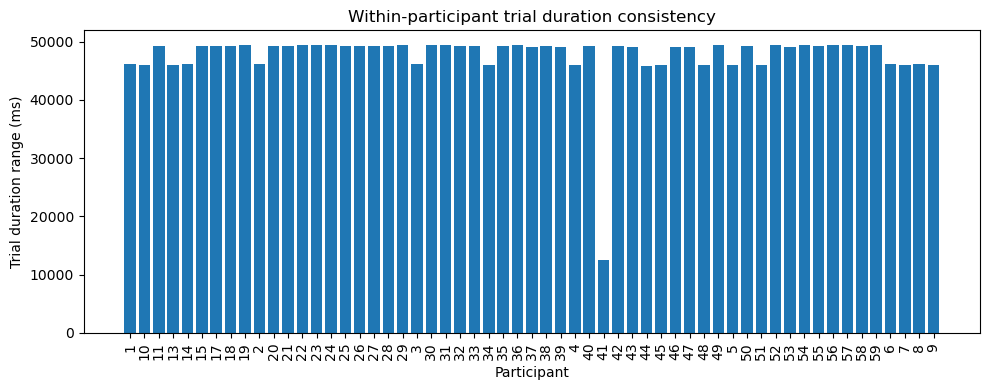

In [22]:
summary = check_trial_length_consistency(
    "../data/by_participant_trimmed",
    tolerance_ms=10
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(summary["participant"], summary["range_ms"])
plt.xticks(rotation=90)
plt.ylabel("Trial duration range (ms)")
plt.xlabel("Participant")
plt.title("Within-participant trial duration consistency")
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
from pathlib import Path


def participant_experiment_duration_table(
    data_dir: str | Path,
    experiment_col: str = "stim_category",
):
    """
    Create a table with:
      rows    = participants
      columns = experiment types
      values  = mean trial duration (ms)
    """
    data_dir = Path(data_dir)
    records = []

    for csv_path in sorted(data_dir.glob("participant_*.csv")):
        pid = csv_path.stem.split("_")[-1]
        df = pd.read_csv(csv_path, low_memory=False)

        required = ["trial", "trial_start_ms", "trial_end_ms", experiment_col]
        if not all(c in df.columns for c in required):
            continue

        df["trial_start_ms"] = pd.to_numeric(df["trial_start_ms"], errors="coerce")
        df["trial_end_ms"] = pd.to_numeric(df["trial_end_ms"], errors="coerce")

        # robust per-trial duration
        trials = (
            df.groupby(["trial", experiment_col])
            .agg(
                start_ms=("trial_start_ms", "min"),
                end_ms=("trial_end_ms", "max"),
            )
            .reset_index()
        )

        trials["duration_ms"] = trials["end_ms"] - trials["start_ms"]
        trials = trials[trials["duration_ms"] > 0]

        for exp, tdf in trials.groupby(experiment_col):
            records.append({
                "participant": pid,
                "experiment": exp,
                "mean_duration_ms": tdf["duration_ms"].mean(),
            })

    long_df = pd.DataFrame(records)

    table = long_df.pivot(
        index="participant",
        columns="experiment",
        values="mean_duration_ms",
    ).sort_index()

    return table

In [17]:
duration_table = participant_experiment_duration_table(
    "../data/by_participant_trimmed",
    experiment_col="stim_category",
)

duration_table

experiment,ballon_left,ballon_right,cat_eyes_left,cat_eyes_right,cat_head_left,cat_head_right,cat_point_left,cat_point_right,cat_voc,cat_voc_left,...,emo_sous_leau,emo_tombe,emo_vole,federica,front_view,goodbye_face,neutral_face,noimage,other_video,vnv_misc
participant,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2884.987000,2759.929,2878.093000,2861.676,2889.004000,2883.5695,NaN,2886.326,...,NaN,NaN,NaN,48886.1050,2870.217500,2887.686500,NaN,NaN,NaN,NaN
10,NaN,NaN,2888.293000,2893.033,2892.217000,2884.602,2883.334000,2891.1825,NaN,2877.744,...,NaN,NaN,NaN,48849.5110,2883.919800,2884.721000,NaN,NaN,NaN,NaN
11,52061.4960,52040.6610,2894.464000,2896.916,2865.003000,2779.800,2880.169500,2873.9385,NaN,2883.795,...,15198.971000,15173.2960,17432.952000,48891.8885,2859.505700,2795.107500,5985.2910,NaN,16293.7550,NaN
13,NaN,NaN,2881.315000,2878.792,2870.577000,2884.495,2893.431000,2870.6730,NaN,2896.639,...,NaN,NaN,NaN,48862.0050,2864.491273,2879.031000,NaN,5292.066000,NaN,48819.8150
14,NaN,NaN,2887.665000,2881.097,2877.738000,2879.956,2823.140500,2887.5900,NaN,2894.075,...,NaN,NaN,NaN,48913.0880,2849.668455,2805.860000,NaN,5296.726316,NaN,48832.7840
15,52058.2520,52050.4220,2887.910000,2891.060,2876.417000,2880.677,2876.206000,2892.3585,NaN,2878.116,...,16807.337000,15179.5860,17099.573000,48866.0950,2866.238818,2871.774500,5953.9960,NaN,15933.4060,48815.7650
17,52065.1150,52054.2340,2895.451000,2891.039,2879.659000,2887.815,2890.203500,2886.2505,NaN,2886.500,...,16296.512667,15120.1090,17414.791500,48913.8570,2883.381273,2875.968500,5974.6870,9106.042353,16294.9170,48823.5870
18,52043.5000,52026.0580,2882.015000,2894.221,2866.958000,2889.087,2877.285500,2847.1950,NaN,2871.458,...,15191.198000,15182.9280,17418.621000,48942.2490,2885.177273,2878.495500,5981.8290,9107.651294,16287.5790,48821.0100
19,52058.4250,52019.7970,2849.075000,2879.087,2889.230000,2894.791,2833.216000,2886.0765,NaN,2893.938,...,15177.833000,15119.4950,17390.729000,48876.2490,2881.009091,2868.732500,5994.1430,9101.735088,16291.2670,48821.1940


In [18]:
# build the table
duration_table = participant_experiment_duration_table(
    data_dir="../data/by_participant_trimmed",
    experiment_col="stim_category",
)

# export to CSV
out_path = "../data/qc_participant_experiment_duration_table.csv"
duration_table.to_csv(out_path)

print(f"Saved table to {out_path}")

Saved table to ../data/qc_participant_experiment_duration_table.csv
